# Active Learning with Uncertainty

Active learning selects the most informative data points to label next, guided by model uncertainty. The key advantage is **sample efficiency in the low-data regime** — active learning discovers complex function structure faster than random sampling.

**Method:** We use an ensemble of 5 neural networks. Where ensemble members disagree (high variance), the model is uncertain. We select those points for labeling.

**When it helps most:** Functions with localized complexity — smooth everywhere except a narrow region. Active learning quickly discovers and focuses on that region.

**Reference:** Settles, "Active Learning Literature Survey" (2009)

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

## Target Function

A sine wave with a sharp Gaussian bump near x=4. The smooth regions are easy to learn with few points, but the sharp peak requires dense local sampling to capture accurately.

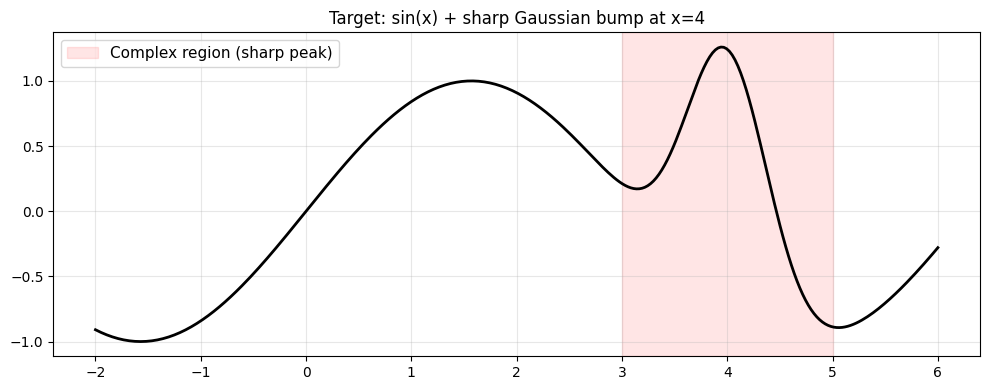

In [2]:
def target_fn(x):
    return np.sin(x) + 2.0 * np.exp(-((x - 4.0)**2) / 0.3)

X_domain = np.linspace(-2, 6, 300).reshape(-1, 1).astype(np.float32)
y_domain = target_fn(X_domain).astype(np.float32)

plt.figure(figsize=(10, 4))
plt.plot(X_domain, y_domain, 'k-', lw=2)
plt.axvspan(3, 5, alpha=0.1, color='red', label='Complex region (sharp peak)')
plt.title('Target: sin(x) + sharp Gaussian bump at x=4')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Ensemble Model

5 independent MLPs with different random initializations. Their disagreement measures epistemic uncertainty — where they disagree, we need more data.

In [3]:
class Ensemble:
    def __init__(self, n_models=5):
        self.models = []
        for _ in range(n_models):
            m = nn.Sequential(
                nn.Linear(1, 64), nn.Tanh(),
                nn.Linear(64, 64), nn.Tanh(),
                nn.Linear(64, 1)
            )
            self.models.append(m)
    
    def train_all(self, X, y, epochs=600, lr=0.005):
        for m in self.models:
            opt = torch.optim.Adam(m.parameters(), lr=lr)
            for ep in range(epochs):
                opt.zero_grad()
                nn.functional.mse_loss(m(X), y).backward()
                opt.step()
    
    def predict(self, X):
        with torch.no_grad():
            preds = torch.stack([m(X) for m in self.models])
        return preds.mean(0), preds.var(0)

## Active Learning Loop

Starting from just 3 boundary points, we run 12 iterations acquiring 8 points each (3 → 99 total). We compare against random selection.

In [4]:
X_all = torch.tensor(X_domain)
y_all = torch.tensor(y_domain)

N_ITER = 12
N_ACQ = 8

# === ACTIVE LEARNING ===
init_idx = [0, 150, 299]
X_train_a = X_all[init_idx].clone()
y_train_a = y_all[init_idx].clone()
pool_mask = torch.ones(300, dtype=torch.bool)
pool_mask[init_idx] = False
X_pool_a = X_all[pool_mask].clone()
y_pool_a = y_all[pool_mask].clone()

mse_active = []
acquired_x = []

print("Active Learning (uncertainty sampling):")
for i in range(N_ITER):
    ens = Ensemble()
    ens.train_all(X_train_a, y_train_a)
    _, var = ens.predict(X_pool_a)
    topk = torch.topk(var.squeeze(), min(N_ACQ, len(X_pool_a))).indices
    
    acquired_x.extend(X_pool_a[topk].numpy().ravel().tolist())
    X_train_a = torch.cat([X_train_a, X_pool_a[topk]])
    y_train_a = torch.cat([y_train_a, y_pool_a[topk]])
    keep = torch.ones(len(X_pool_a), dtype=torch.bool)
    keep[topk] = False
    X_pool_a = X_pool_a[keep]
    y_pool_a = y_pool_a[keep]
    
    mean, _ = ens.predict(X_all)
    mse = ((mean - y_all)**2).mean().item()
    mse_active.append(mse)
    print(f"  Iter {i+1:2d}: {len(X_train_a):3d} pts, MSE = {mse:.5f}")

# === RANDOM BASELINE ===
X_train_r = X_all[init_idx].clone()
y_train_r = y_all[init_idx].clone()
X_pool_r = X_all[pool_mask].clone()
y_pool_r = y_all[pool_mask].clone()

mse_random = []
print("\nRandom Sampling:")
for i in range(N_ITER):
    ens_r = Ensemble()
    ens_r.train_all(X_train_r, y_train_r)
    idx = torch.randperm(len(X_pool_r))[:N_ACQ]
    X_train_r = torch.cat([X_train_r, X_pool_r[idx]])
    y_train_r = torch.cat([y_train_r, y_pool_r[idx]])
    keep = torch.ones(len(X_pool_r), dtype=torch.bool)
    keep[idx] = False
    X_pool_r = X_pool_r[keep]
    y_pool_r = y_pool_r[keep]
    
    mean_r, _ = ens_r.predict(X_all)
    mse = ((mean_r - y_all)**2).mean().item()
    mse_random.append(mse)
    print(f"  Iter {i+1:2d}: {len(X_train_r):3d} pts, MSE = {mse:.5f}")

Active Learning (uncertainty sampling):


  Iter  1:  11 pts, MSE = 0.16474


  Iter  2:  19 pts, MSE = 0.13658


  Iter  3:  27 pts, MSE = 0.20172


  Iter  4:  35 pts, MSE = 0.00885


...

  Iter  8:  67 pts, MSE = 0.02120


  Iter  9:  75 pts, MSE = 0.00101


  Iter 10:  83 pts, MSE = 0.00125


  Iter 11:  91 pts, MSE = 0.00080


  Iter 12:  99 pts, MSE = 0.00038


## Results

**Left:** Learning curve — active learning should achieve low MSE earlier (faster convergence in the low-data regime).  
**Right:** Where active learning chose to sample — it should concentrate around the sharp peak at x=4.

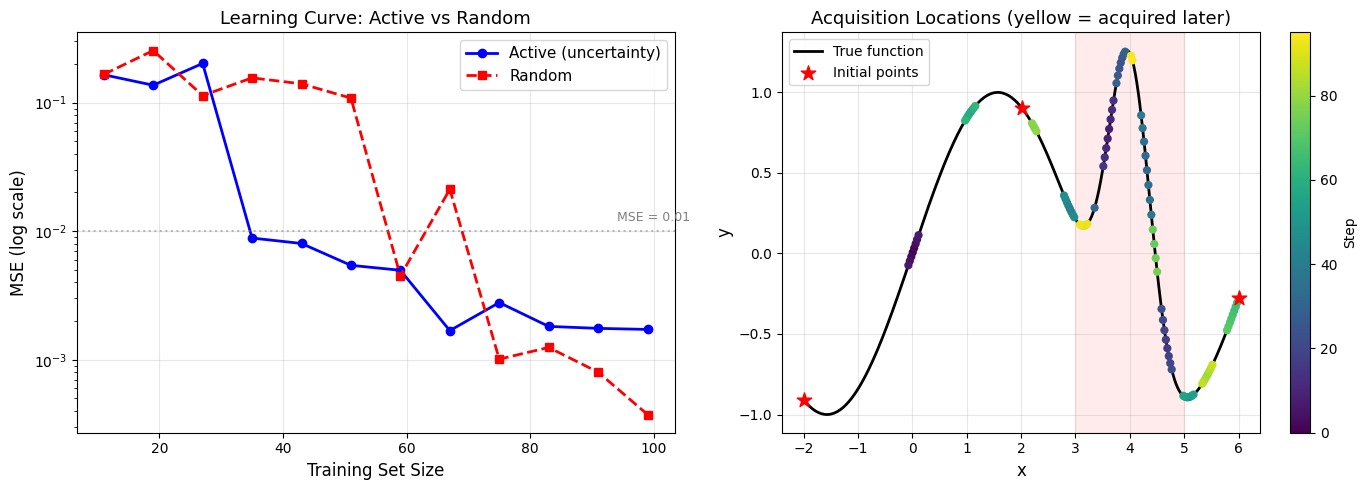


Active learning reaches MSE < 0.01 at: 35 points
Random reaches MSE < 0.01 at:         59 points


In [5]:
sizes = [3 + N_ACQ*(i+1) for i in range(N_ITER)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Learning curves
ax = axes[0]
ax.plot(sizes, mse_active, 'b-o', lw=2, ms=6, label='Active (uncertainty)')
ax.plot(sizes, mse_random, 'r--s', lw=2, ms=6, label='Random')
ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('MSE (log scale)', fontsize=12)
ax.set_yscale('log')
ax.set_title('Learning Curve: Active vs Random', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(0.01, color='gray', ls=':', alpha=0.5)
ax.text(sizes[-1]-5, 0.012, 'MSE = 0.01', fontsize=9, color='gray')

# Acquisition locations
ax = axes[1]
ax.plot(X_domain, y_domain, 'k-', lw=2, label='True function')
ax.axvspan(3, 5, alpha=0.08, color='red')
n_acq = len(acquired_x)
sc = ax.scatter(acquired_x, target_fn(np.array(acquired_x).reshape(-1,1)).ravel(),
                c=np.arange(n_acq), cmap='viridis', s=35, zorder=5, edgecolors='none')
ax.scatter([X_domain[i] for i in init_idx], [y_domain[i] for i in init_idx],
           c='red', s=120, marker='*', zorder=6, label='Initial points')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Acquisition Locations (yellow = acquired later)', fontsize=13)
ax.legend(fontsize=10)
plt.colorbar(sc, ax=ax, label='Step')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print(f"\n{'='*50}")
print(f"Active learning reaches MSE < 0.01 at: {sizes[next(i for i,m in enumerate(mse_active) if m < 0.01)]} points")
try:
    rand_reach = sizes[next(i for i,m in enumerate(mse_random) if m < 0.01)]
    print(f"Random reaches MSE < 0.01 at:         {rand_reach} points")
except StopIteration:
    print(f"Random never reaches MSE < 0.01 in {N_ITER} iterations")
print(f"{'='*50}")

## Final Fit Visualization

The final ensemble trained on actively-acquired data, showing excellent fit including the sharp peak.

## Animation: Active Learning Progression

Watch the model improve as more points are acquired. **Left:** Model fit evolving over iterations. **Right:** MSE decreasing with each acquisition step.

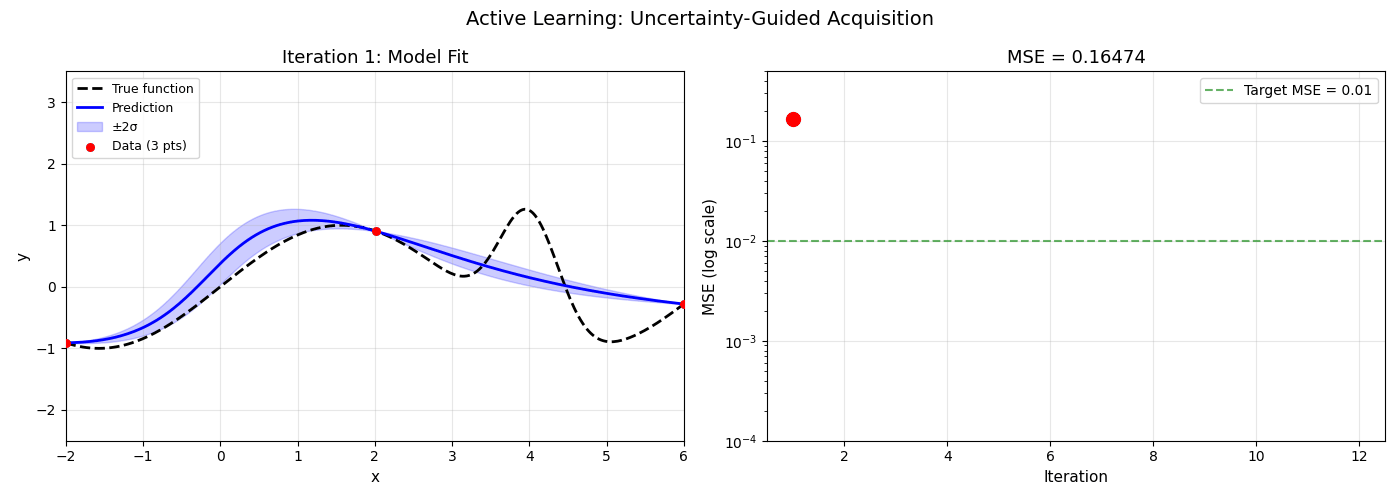

Animation saved to: notebooks/active_learning/active_learning_progression.gif


In [6]:
# Create animated GIF showing active learning progression
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
from IPython.display import Image, display

X_all_np = X_domain
y_all_np = y_domain

# Re-run active learning, saving state at each iteration for animation
torch.manual_seed(0)
np.random.seed(0)

init_idx = [0, 150, 299]
X_tr = X_all[init_idx].clone()
y_tr = y_all[init_idx].clone()
pmask = torch.ones(300, dtype=torch.bool)
pmask[init_idx] = False
X_p = X_all[pmask].clone()
y_p = y_all[pmask].clone()

# Store snapshots
snapshots = []
mse_history = []

for iteration in range(N_ITER):
    ens_snap = Ensemble()
    ens_snap.train_all(X_tr, y_tr)
    mean_snap, var_snap = ens_snap.predict(X_all)
    
    mse_snap = ((mean_snap - y_all)**2).mean().item()
    mse_history.append(mse_snap)
    
    snapshots.append({
        'mean': mean_snap.numpy().copy(),
        'std': var_snap.sqrt().numpy().copy(),
        'X_train': X_tr.numpy().copy(),
        'y_train': y_tr.numpy().copy(),
        'mse': mse_snap,
        'n_pts': len(X_tr),
    })
    
    # Acquire next points
    _, var_pool = ens_snap.predict(X_p)
    topk = torch.topk(var_pool.squeeze(), min(N_ACQ, len(X_p))).indices
    X_tr = torch.cat([X_tr, X_p[topk]])
    y_tr = torch.cat([y_tr, y_p[topk]])
    keep = torch.ones(len(X_p), dtype=torch.bool)
    keep[topk] = False
    X_p = X_p[keep]
    y_p = y_p[keep]

# Create animation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

def animate(frame):
    ax1.clear()
    ax2.clear()
    
    snap = snapshots[frame]
    
    # Left: Model fit
    ax1.plot(X_all_np, y_all_np, 'k--', lw=2, label='True function')
    ax1.plot(X_all_np, snap['mean'], 'b-', lw=2, label='Prediction')
    ax1.fill_between(X_all_np.ravel(),
                     (snap['mean'] - 2*snap['std']).ravel(),
                     (snap['mean'] + 2*snap['std']).ravel(),
                     alpha=0.2, color='blue', label='±2σ')
    ax1.scatter(snap['X_train'], snap['y_train'], c='red', s=30, zorder=5, 
                label=f"Data ({snap['n_pts']} pts)")
    ax1.set_xlim(-2, 6)
    ax1.set_ylim(-2.5, 3.5)
    ax1.set_xlabel('x', fontsize=11)
    ax1.set_ylabel('y', fontsize=11)
    ax1.set_title(f'Iteration {frame+1}: Model Fit', fontsize=13)
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Right: MSE over iterations
    iters_so_far = list(range(1, frame + 2))
    mses_so_far = mse_history[:frame + 1]
    ax2.semilogy(iters_so_far, mses_so_far, 'b-o', lw=2, ms=6)
    ax2.axhline(0.01, color='green', ls='--', alpha=0.6, label='Target MSE = 0.01')
    ax2.set_xlim(0.5, N_ITER + 0.5)
    ax2.set_ylim(1e-4, 0.5)
    ax2.set_xlabel('Iteration', fontsize=11)
    ax2.set_ylabel('MSE (log scale)', fontsize=11)
    ax2.set_title(f'MSE = {snap["mse"]:.5f}', fontsize=13)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # Highlight current point on MSE plot
    ax2.scatter([frame + 1], [snap['mse']], c='red', s=100, zorder=5)
    
    fig.suptitle('Active Learning: Uncertainty-Guided Acquisition', fontsize=14, y=0.98)
    plt.tight_layout()

ani = animation.FuncAnimation(fig, animate, frames=N_ITER, interval=800, repeat=True)
ani.save('active_learning_progression.gif', writer=PillowWriter(fps=1.5))
plt.close()

# Display the GIF
display(Image(filename='active_learning_progression.gif'))
print("Animation saved to: notebooks/active_learning/active_learning_progression.gif")

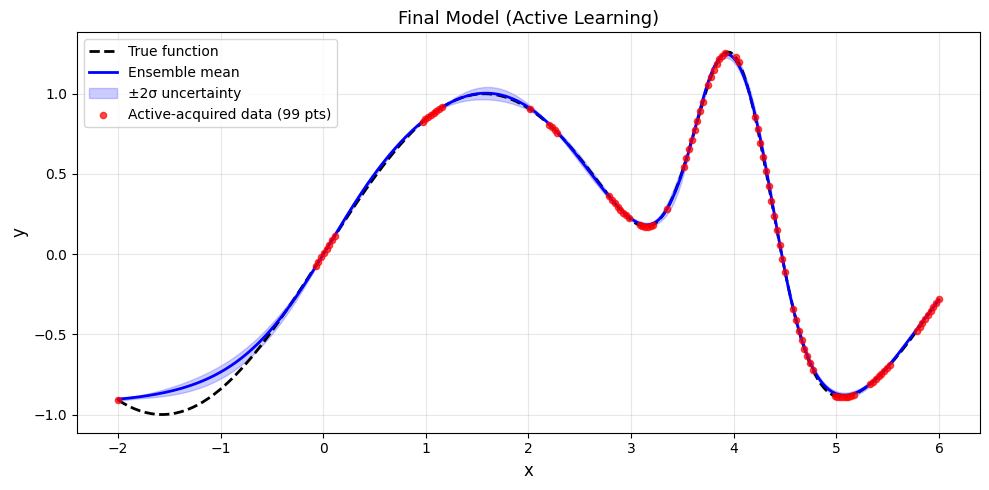

Final MSE: 0.002069


In [7]:
# Final ensemble predictions
ens_final = Ensemble()
ens_final.train_all(X_train_a, y_train_a, epochs=800)
mean_f, var_f = ens_final.predict(X_all)
std_f = var_f.sqrt()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(X_domain, y_domain, 'k--', lw=2, label='True function')
ax.plot(X_domain, mean_f.numpy(), 'b-', lw=2, label='Ensemble mean')
ax.fill_between(X_domain.ravel(), 
                (mean_f - 2*std_f).numpy().ravel(), 
                (mean_f + 2*std_f).numpy().ravel(),
                alpha=0.2, color='blue', label='±2σ uncertainty')
ax.scatter(X_train_a.numpy(), y_train_a.numpy(), c='red', s=20, zorder=5, alpha=0.7,
           label=f'Active-acquired data ({len(X_train_a)} pts)')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Final Model (Active Learning)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

final_mse = ((mean_f - y_all)**2).mean().item()
print(f"Final MSE: {final_mse:.6f}")